# Epidemic simulation on network

###### Author: Elisabetta Salvai

In [1]:
import networkx as nx
import numpy as np
import random
import math
import powerlaw as pwl
import EoN as eon
import pandas as pd
import matplotlib.patches as mpatches

from tqdm.notebook import tqdm
from collections import Counter, defaultdict
from scipy.stats import pearsonr, moment, ttest_ind
from statistics import variance, mean
from sklearn.metrics import normalized_mutual_info_score as nmi
from heapq import nlargest

%pylab inline

Populating the interactive namespace from numpy and matplotlib


C:\ProgramData\Anaconda3\lib\site-packages\IPython\core\magics\pylab.py:159: UserWarning: pylab import has clobbered these variables: ['random', 'mean']
`%matplotlib` prevents importing * from pylab and numpy
  warn("pylab import has clobbered these variables: %s"  % clobbered +


Loading data form http://snap.stanford.edu/data/ca-AstroPh.html.

In [2]:
filepath = './CA-AstroPh.txt'

G = nx.Graph()

fh = open(filepath, 'r')

# reading all the file lines
for line in fh.readlines():
    # remove "\n" characters (.strip()) and split the line at blank spaces (split.())
    s = line.strip().split()
    if s[0] != '#':
        # the first lines are comments
        origin = int(s[0])
        dest = int(s[1])
        
        G.add_edge(origin,dest)
    
# closing file
fh.close()

## Index

1. [Dataset statistic](#dat_stat)
1. [Connectivity study](#connectivity)
1. [Degree distribution](#degree)
1. [Centrality measures](#centrality)
    1. [Closeness](#clo)
    1. [Betweenness](#bet)
    1. [Eigenvector centrality](#eigen)
    1. [Pagerank](#pr)
    1. [Correlations](#corr)
1. [Path analysis](#pa)
1. [Clustering coefficient](#cc)
1. [Epidemic simulation](#epsim)
    1. [Vary beta](#beta)
    1. [Vary mu](#mu)
    1. [Silent population](#sil_pop)
        1. [Degree](#deg_sil)
        1. [Closeness](#clo_sil)
        1. [Betweenness](#bet_sil)
        1. [Eigenvector centrality](#eig_sil)
        1. [Pagerank](#pr_sil)

<a id='dat_stat'></a>

## Dataset statistics

| Feautures | Measure |
|:---:|:---:|
| Nodes	| 18772 |
| Edges	| 198110 |
| Nodes in largest WCC | 17903 (0.954) |
| Edges in largest WCC | 197031 (0.995) |
| Nodes in largest SCC | 17903 (0.954) |
| Edges in largest SCC | 197031 (0.995) |
| Average clustering coefficient | 0.6306 |
| Number of triangles | 1351441 |
| Fraction of closed triangles | 0.1345 |
| Diameter (longest shortest path) | 14 |

In [3]:
g_size = G.number_of_nodes() # N number of nodes
edges = G.number_of_edges() # L number of edges
av_degree = 2*edges/g_size # average degree

print("The graph has", g_size, "nodes and", edges, "edges")
print("The average degree is {:.3f}".format(av_degree))

The graph has 18772 nodes and 198110 edges
The average degree is 21.107


In [4]:
density = av_degree/(g_size - 1)
print("d = {:.5f}".format(density))

d = 0.00112


<a id ='connectivity'></a>

## Connectivity study

In [5]:
print('The graph is connected?', nx.is_connected(G))

The graph is connected? False


In [6]:
num_conn_components = nx.number_connected_components(G)
print('The graph is divided in', num_conn_components, 'components.')

The graph is divided in 290 components.


In [7]:
size = []
components = [i for i in nx.connected_components(G)] # list with components

for i in range(len(components)):

    size.append(len(components[i])) # size of each components

In [8]:
print('Number of nodes in giant component = ', max(size))

Number of nodes in giant component =  17903


In [9]:
size_distr = Counter(size)

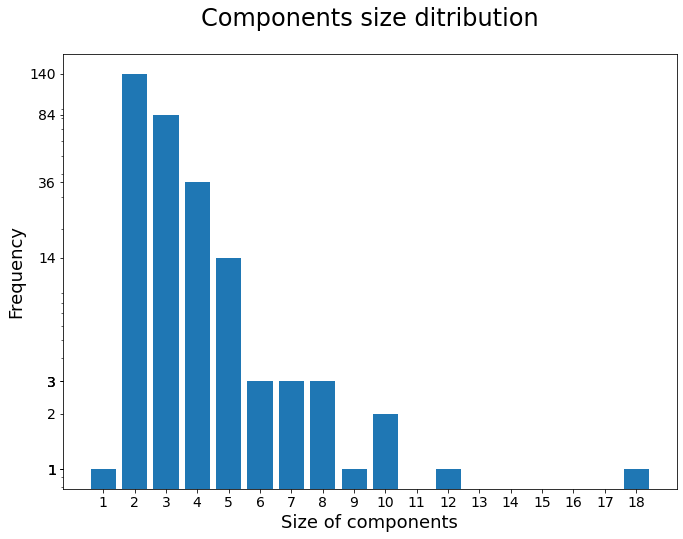

In [10]:
plt.figure(figsize=(11,8))
plt.title('Components size ditribution', fontsize=24, y = 1.05)

# excluded giant component from the plot

plt.bar([key for key, value in size_distr.items() if key != 17903], [value for key, value in size_distr.items() if key != 17903])

plt.xlabel('Size of components', fontsize=18)
plt.ylabel('Frequency', fontsize=18)

# setting x ticks 
plt.xticks(range(min([key for key, value in size_distr.items() if key != 17903]),
                 max([key for key, value in size_distr.items() if key != 17903]) + 1))

# setting y ticks and scale

plt.yscale('log')
tick_pos = [value for key, value in size_distr.items() if key != 17903]
plt.yticks(tick_pos, tick_pos)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14);

In [11]:
size = [i for i in (map(lambda x: len(x), components))]
size_max = max(size)
index_max = size.index(size_max)
giant_component = G.subgraph(components[index_max])

In [12]:
gc_size = giant_component.number_of_nodes() # number of nodes 
gc_edges = giant_component.number_of_edges() # number of edges
gc_av_degree = 2*gc_edges/gc_size # average degree
size_proportion = gc_size/g_size # proportion of nodes in gc
edges_proportion = gc_edges/edges # proportion of edges in gc

print("The giant component has", gc_size, "nodes,", round(size_proportion, 3), "of total nodes.")
print("The giant component has", gc_edges, "edges,", round(edges_proportion, 3), "of total edges.")

The giant component has 17903 nodes, 0.954 of total nodes.
The giant component has 197031 edges, 0.995 of total edges.


In [13]:
H = [] # array containing subgraph that are the connected components
comp_edges = [] # same but with edges
comp_av_degree = [] # same but with average degrees

for i in range(num_conn_components):
    
    H.append(G.subgraph(components[i]))
    comp_edges.append(len((H[i]).edges()))
    comp_av_degree.append(2*comp_edges[i]/size[i])

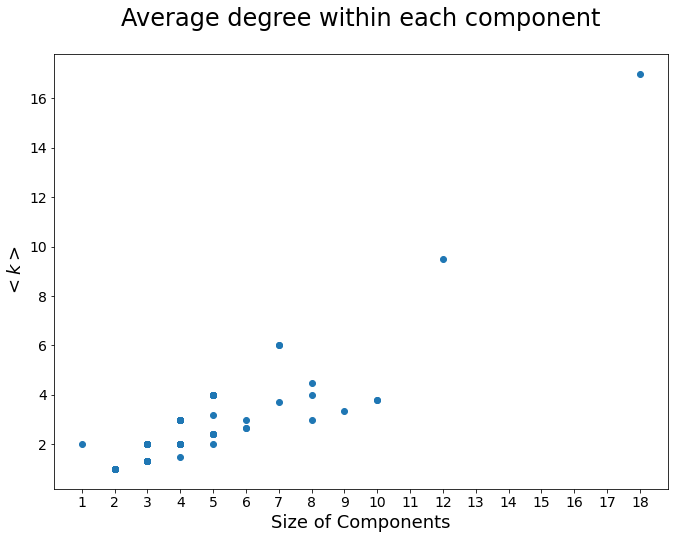

In [14]:
# excluding giant component from the analysis
size_components = [i for i in size if i != 17903] 
av_degree_components = [i for i in comp_av_degree if i != gc_av_degree] 

plt.figure(figsize=(11,8))
plt.title('Average degree within each component', fontsize=24, y = 1.05)
plt.grid()   
plt.scatter(size_components, av_degree_components, zorder=2.5)

plt.xlabel('Size of Components', fontsize=18)
plt.ylabel('$<k>$', fontsize=18)

plt.xticks(range(min([key for key, value in size_distr.items() if key != 17903]), max([key for key, value in size_distr.items() if key != 17903]) + 1))
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.grid();

In [15]:
pearson, p_value = pearsonr(size_components, av_degree_components)
print("Pearson statistic = {:.3f}".format(pearson), "\nP value = {:.3e}".format(p_value))

Pearson statistic = 0.909 
P value = 6.185e-111


In [16]:
gc_density = gc_av_degree/(gc_size - 1)
print("d = {:.5f}".format(gc_density))

d = 0.00123


<a id='degree'></a>

## Degree distribution 

- **Whole network**

In [17]:
degree = list(dict(G.degree()).values())
deg_distr = Counter(degree)
# degree variance
deg_var = variance(degree)
# 2nd moment of degree distiribution 
av_k2 = np.sum(np.fromiter((deg**2 for deg in degree), dtype=np.float64))/g_size
# maximum degree
deg_max = max(degree)
# minimum degree
deg_min = min(degree)

In [18]:
print("******        Degree         *****")
print("Average degree = {:.3f} ± {:.3f}".format(av_degree, sqrt(deg_var)))
print("Maximum degree =", deg_max)
print("Minumum degree =", deg_min)

******        Degree         *****
Average degree = 21.107 ± 30.572
Maximum degree = 504
Minumum degree = 1


In [19]:
heterogeneity = av_k2/(av_degree*av_degree)
print("Heterogeneity parameter = {:.3f}".format(heterogeneity))

Heterogeneity parameter = 3.098


In [20]:
x = list(deg_distr.keys())
y = [distr/g_size for distr in deg_distr.values()]

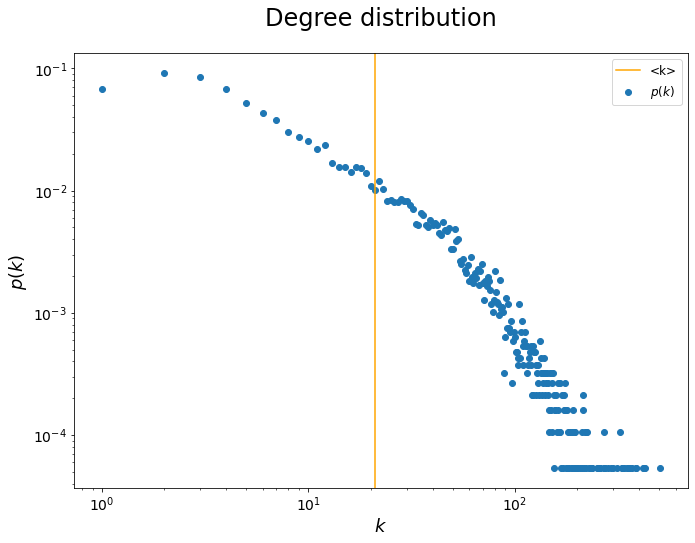

In [21]:
plt.figure(figsize=(11,8))
plt.scatter(x, y, label='$p(k)$')
plt.axvline(x=av_degree, label='<k>', color='orange', linestyle='-')

plt.title("Degree distribution", y=1.05, fontsize=24)
plt.xlabel('$k$', fontsize=18)
plt.ylabel('$p(k)$', fontsize=18)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.yscale('log')
plt.xscale('log')
plt.legend(loc='best', fontsize=12);

In [22]:
fit_function = pwl.Fit(x) # power law fit on degree values
gamma = fit_function.power_law.alpha # estimated exponent 
err_gamma = fit_function.power_law.sigma # error on estimated exponent

print("***       ***       ***       ***       ***")
print("Estimated value for gamma = {:.3f} ± {:.3f}".format(gamma, err_gamma))
print("Optimal k min value = ", int(fit_function.power_law.xmin))
print("Kolmogorov-Smirnov distance = {:.3f}".format(fit_function.power_law.D) )

Calculating best minimal value for power law fit
***       ***       ***       ***       ***
Estimated value for gamma = 4.089 ± 0.409
Optimal k min value =  188
Kolmogorov-Smirnov distance = 0.089


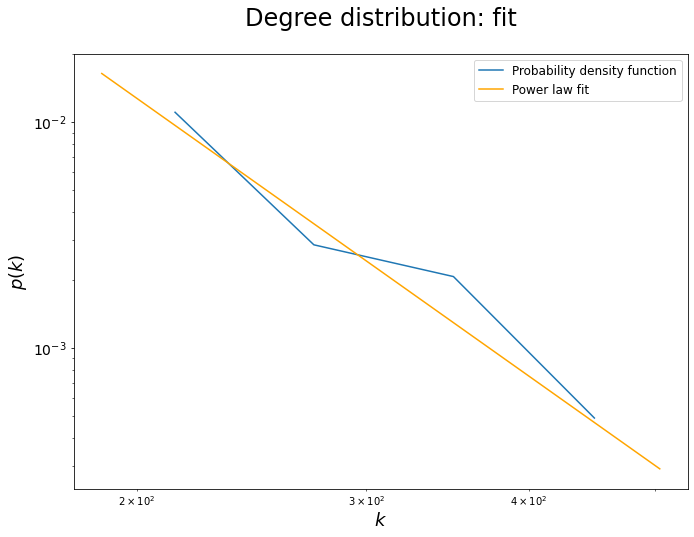

In [23]:
fig = plt.figure(figsize=(11,8))

fig = pwl.plot_pdf(
                   [x for x in degree if x >= fit_function.power_law.xmin],
                   label='Probability density function'
                   )

fit_function.power_law.plot_pdf(ax=fig, linestyle='-', color='orange', label='Power law fit')

plt.title("Degree distribution: fit", y=1.05, fontsize=24)
plt.xlabel('$k$', fontsize=18)
plt.ylabel('$p(k)$', fontsize=18)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.yscale('log')
plt.xscale('log')
plt.legend(loc='best', fontsize=12);

- **Giant component**

In [24]:
gc_degree = list(dict(giant_component.degree()).values())
gc_deg_distr = Counter(gc_degree)
# degree variance
gc_deg_var = variance(gc_degree)
# 2nd moment of degree distiribution 
gc_av_k2 = np.sum(np.fromiter((deg**2 for deg in gc_degree), dtype=np.float64))/gc_size
# maximum degree
gc_deg_max = max(gc_degree)
# minimum degree
gc_deg_min = min(gc_degree)

In [25]:
print("******        Degree         *****")
print("Average degree = {:.3f} ± {:.3f}".format(gc_av_degree, sqrt(gc_deg_var)))
print("Maximum degree =", gc_deg_max)
print("Minumum degree =", gc_deg_min)

******        Degree         *****
Average degree = 22.011 ± 31.017
Maximum degree = 504
Minumum degree = 1


In [26]:
gc_heterogeneity = gc_av_k2/(gc_av_degree*gc_av_degree)
print("Heterogeneity parameter = {:.3f}".format(gc_heterogeneity))

Heterogeneity parameter = 2.986


Il plot coi dati della giant component non lo faccio perché è troppo uguale a quello del network tutto.

<a id='centrality'></a>

## Centrality measures

<a id='clo'></a>

- **Closeness centrality**

In [27]:
degree_gc = [] # array with nodes degree 
closeness = [] # nodes closeness

filename1 = 'Metric/closeness.txt'

# loading data
data1 = np.loadtxt(filename1, delimiter=' ', skiprows=1, dtype=str)

for i in range(len(data1)):

    degree_gc.append(int(data1[i][1]))
    closeness.append(float(data1[i][2]))

mean_closeness = mean(closeness)
std_closeness = np.std(closeness)

In [28]:
print('closeness = {:.3f} ± {:.3f}'.format(mean_closeness, std_closeness))

closeness = 0.244 ± 0.034


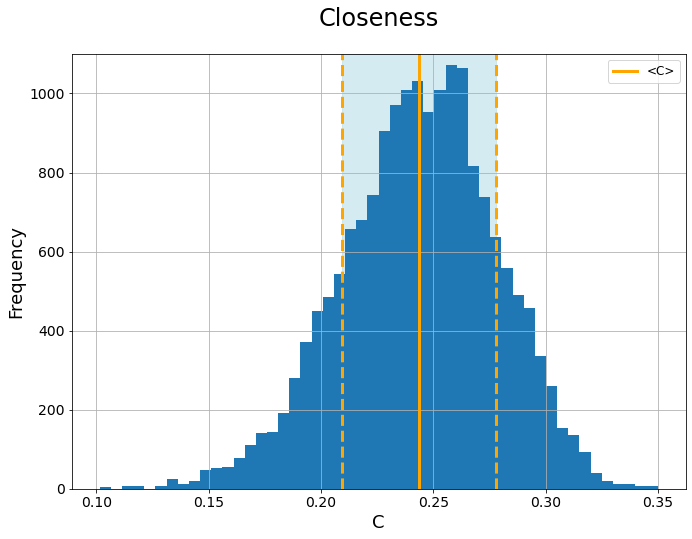

In [29]:
plt.figure(figsize=(11,8))
plt.title('Closeness', fontsize=24, y = 1.05)

plt.hist(closeness, bins=50)
plt.axvline(x=mean_closeness, label='<C>', color='orange', linestyle='-', linewidth=3)
plt.axvline(x=mean_closeness - std_closeness, color='orange', linestyle='--', linewidth=3)
plt.axvline(x=mean_closeness + std_closeness, color='orange', linestyle='--', linewidth=3)

plt.ylim(0, 1100)

plt.fill_between([mean_closeness - std_closeness, mean_closeness + std_closeness], plt.ylim()[1] + 1, color='lightblue', alpha=0.5)

plt.xlabel('C', fontsize=18)
plt.ylabel('Frequency', fontsize=18)
plt.tick_params(axis='both', labelsize=14)
plt.legend(loc='best', fontsize=12)
plt.grid(True);

<a id='bet'></a>

- **Betweenness centrality**

In [30]:
betweenness = [] # nodes betweenness

filename2 = 'Metric/betweenness.txt'

# loading data 
data2 = np.loadtxt(filename2, delimiter = ' ', skiprows = 1, dtype = str)

for i in range(len(data2)):

    betweenness.append(float(data2[i][1]))

mean_betweenness = mean(betweenness)
std_betweenness = np.std(betweenness)

In [31]:
print('betweenness = {:.2e} ± {:.2e}'.format(mean_betweenness, std_betweenness))

betweenness = 1.78e-04 ± 5.79e-04


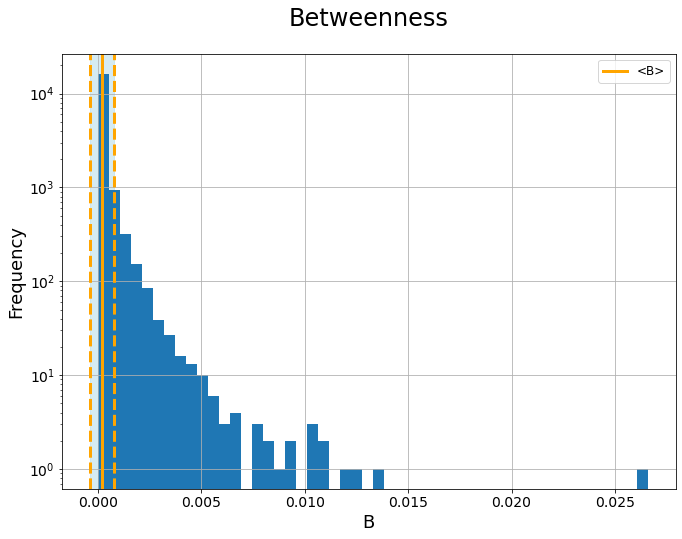

In [32]:
plt.figure(figsize=(11,8))
plt.title('Betweenness', fontsize=24, y = 1.05)

plt.hist(betweenness, bins=50)
plt.axvline(x=mean_betweenness, label='<B>', color='orange', linestyle='-', linewidth=3)
plt.axvline(x=mean_betweenness - std_betweenness, color='orange', linestyle='--', linewidth=3)
plt.axvline(x=mean_betweenness + std_betweenness, color='orange', linestyle='--', linewidth=3)

plt.yscale('log')

ylim_min = plt.ylim()[0]
ylim_max = plt.ylim()[1]


plt.fill_between([mean_betweenness - std_betweenness, mean_betweenness + std_betweenness], plt.ylim()[1] + 10000, color='lightblue', alpha=0.5)

plt.ylim(ylim_min, ylim_max)

plt.xlabel('B', fontsize=18)
plt.ylabel('Frequency', fontsize=18)

plt.tick_params(axis='both', labelsize=14)
plt.legend(loc='best', fontsize=12)
plt.grid(True);

<a id='eigen'></a>

- **Eigenvector centrality**

In [33]:
%%time

eigenvec = nx.eigenvector_centrality(giant_component, max_iter=1000, tol= 1e-06)

eigenvector = list(eigenvec.values())

mean_eigenvector = mean(eigenvector)
std_eigenvector = np.std(eigenvector)

Wall time: 20.6 s


In [34]:
print("Eigenvector centrality = {:.2e} ± {:.2e}".format(mean_eigenvector, std_eigenvector))

Eigenvector centrality = 2.40e-03 ± 7.08e-03


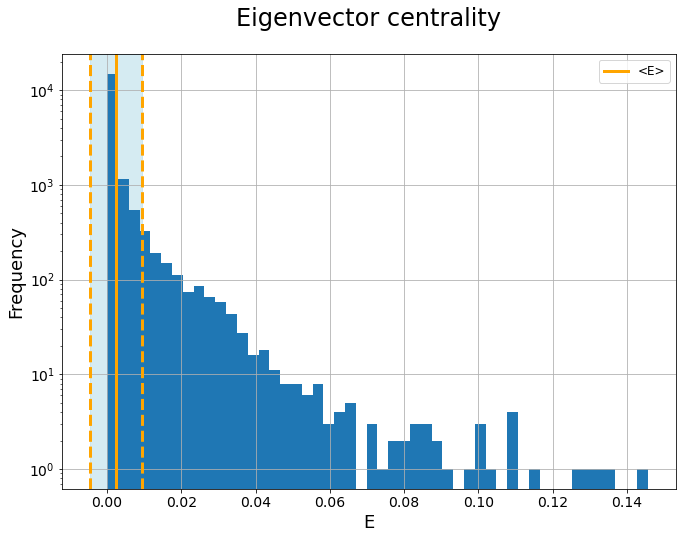

In [35]:
plt.figure(figsize=(11,8))
plt.title('Eigenvector centrality', fontsize=24, y = 1.05)

plt.hist(eigenvector, bins=50)
plt.axvline(x=mean_eigenvector, label='<E>', color='orange', linestyle='-', linewidth=3)
plt.axvline(x=mean_eigenvector - std_eigenvector, color='orange', linestyle='--', linewidth=3)
plt.axvline(x=mean_eigenvector + std_eigenvector, color='orange', linestyle='--', linewidth=3)

plt.yscale('log')

ylim_min = plt.ylim()[0]
ylim_max = plt.ylim()[1]

plt.fill_between([mean_eigenvector - std_eigenvector, mean_eigenvector + std_eigenvector], plt.ylim()[1] + 1, color='lightblue', alpha=0.5)

plt.ylim(ylim_min, ylim_max)

plt.xlabel('E', fontsize=18)
plt.ylabel('Frequency', fontsize=18)
plt.tick_params(axis='both', labelsize=14)
plt.legend(loc='best', fontsize=12)
plt.grid(True);

- **Pagerank**

In [36]:
%%time

pr = nx.pagerank(giant_component, 0.8)

pagerank = list(pr.values())

mean_pagerank = mean(pagerank)
std_pagerank = np.std(pagerank)

Wall time: 2.58 s


In [37]:
print("Pagerank = {:.2e} ± {:.2e}".format(mean_pagerank, std_pagerank))

Pagerank = 5.59e-05 ± 4.72e-05


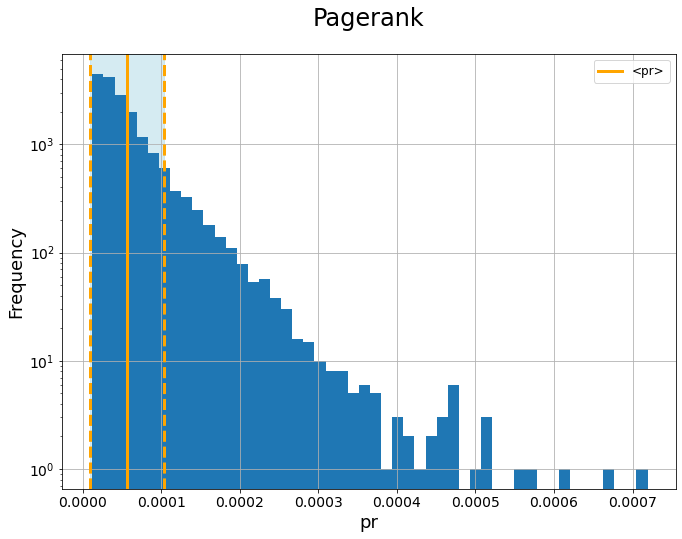

In [38]:
plt.figure(figsize=(11,8))
plt.title('Pagerank', fontsize=24, y = 1.05)

plt.hist(pagerank, bins=50)
plt.axvline(x=mean_pagerank, label='<pr>', color='orange', linestyle='-', linewidth=3)
plt.axvline(x=mean_pagerank - std_pagerank, color='orange', linestyle='--', linewidth=3)
plt.axvline(x=mean_pagerank + std_pagerank, color='orange', linestyle='--', linewidth=3)

plt.yscale('log')

ylim_min = plt.ylim()[0]
ylim_max = plt.ylim()[1]

plt.fill_between([mean_pagerank - std_pagerank, mean_pagerank + std_pagerank], plt.ylim()[1] + 1, color='lightblue', alpha=0.5)

plt.ylim(ylim_min, ylim_max)

plt.xlabel('pr', fontsize=18)
plt.ylabel('Frequency', fontsize=18)
plt.tick_params(axis='both', labelsize=14)
plt.legend(loc='best', fontsize=12)
plt.grid(True);

<a id='corr'></a>

- **Correlations**

In [39]:
centrality = [degree_gc, closeness, betweenness, eigenvector, pagerank]

In [40]:
# Inizializza la matrice di mutual information
correlations = np.zeros((len(centrality), len(centrality)))

# Calcola la mutual information per ogni coppia di misure
for i in range(len(centrality)):
    
    for j in range(len(centrality)):
        
        if i!= j:
        
            correlations[i, j] = nmi(centrality[i], centrality[j])

C:\Users\elisabetta\AppData\Roaming\Python\Python39\site-packages\sklearn\metrics\cluster\_supervised.py:64: UserWarning: Clustering metrics expects discrete values but received multiclass values for label, and continuous values for target
  warnings.warn(msg, UserWarning)
C:\Users\elisabetta\AppData\Roaming\Python\Python39\site-packages\sklearn\metrics\cluster\_supervised.py:64: UserWarning: Clustering metrics expects discrete values but received multiclass values for label, and continuous values for target
  warnings.warn(msg, UserWarning)
C:\Users\elisabetta\AppData\Roaming\Python\Python39\site-packages\sklearn\metrics\cluster\_supervised.py:64: UserWarning: Clustering metrics expects discrete values but received multiclass values for label, and continuous values for target
  warnings.warn(msg, UserWarning)
C:\Users\elisabetta\AppData\Roaming\Python\Python39\site-packages\sklearn\metrics\cluster\_supervised.py:64: UserWarning: Clustering metrics expects discrete values but received 

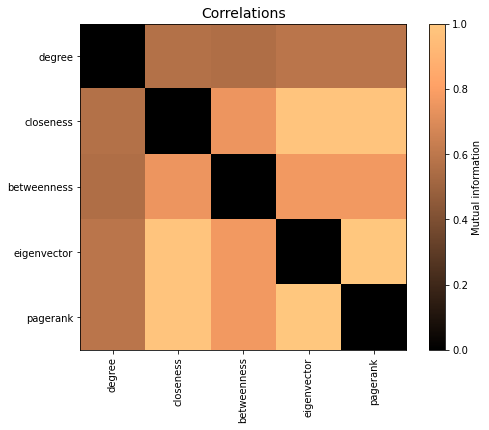

<Figure size 432x288 with 0 Axes>

In [41]:
label =['degree', 'closeness', 'betweenness', 'eigenvector', 'pagerank']

plt.figure(figsize=(8, 6))
plt.imshow(correlations, cmap='copper', vmin=0, vmax=1)
plt.colorbar(label='Mutual information')
plt.title('Correlations', fontsize=14)
plt.xticks(range(len(label)), label, rotation=90) 
plt.yticks(range(len(label)), label)
plt.grid(False)

plt.show()

plt.savefig('correlations.png')

<a id='pa'></a>

## Path analysis

In [42]:
# loading data 
filename3 = 'Metric/path_analysis.txt'

data3 = np.loadtxt(filename3, delimiter = ' ', skiprows=1, dtype=str)

d_av = float(data3[0]) # average shortest path
d_max = int(data3[1]) # diameter

In [43]:
print("Average shortest path = {:.3f}".format(d_av))
print("Diameter =", d_max)

Average shortest path = 4.194
Diameter = 14


In [44]:
print("ln(N) = {:.3f}".format(math.log(g_size)))
print("ln(ln(N)) = {:.3f}".format( math.log(math.log(g_size))))

ln(N) = 9.840
ln(ln(N)) = 2.286


In [45]:
# longest shortest path per each node
longest_sp = np.loadtxt('Metric/longest_shortest_path.txt').astype(np.int64)

In [46]:
d_max_est = max(longest_sp) # maximum of previous array
mean_lsp = mean(longest_sp) # mean of previous array
print('Estimated diameter = ', d_max_est)
print('Mean of longest sp = {:.3f}'.format(mean_lsp))

Estimated diameter =  14
Mean of longest sp = 9.984


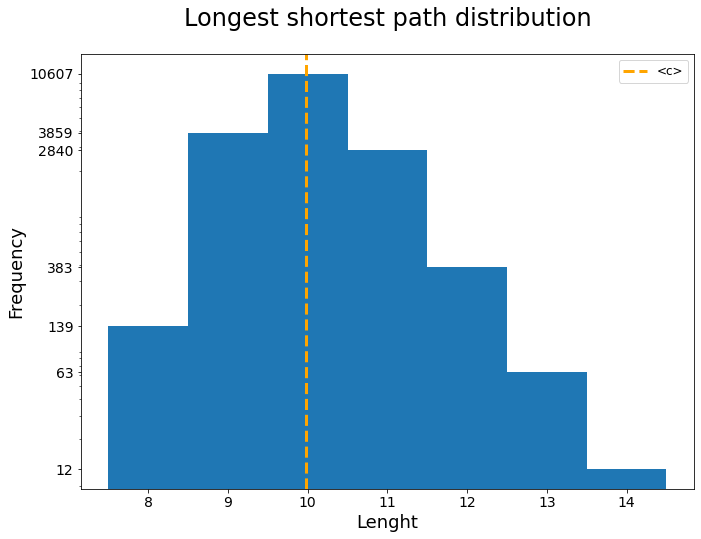

In [47]:
bin = [x - 0.5 for x in range(min(longest_sp), max(longest_sp) + 2)]

plt.figure(figsize=(11,8))
plt.title('Longest shortest path distribution', fontsize=24, y=1.05)

#plt.hist(longest_sp, bins=bin)

# Calcola l'istogramma delle frequenze
counts, _, _ = plt.hist(longest_sp, bins=bin)

plt.axvline(x=mean_lsp, color='orange', linestyle='--', linewidth=3, label='<c>')

plt.xlabel('Lenght', fontsize=18)
plt.ylabel('Frequency', fontsize=18)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.yscale('log')
plt.yticks(counts, counts.astype(int), fontsize=14)  # Imposta i valori dei tick come le frequenze effettive

plt.legend(loc='best', fontsize=12);

<a id='cc'></a>

## Clustering coefficient

In [48]:
%%time

av_clust_coeff = nx.average_clustering(G) # whole network
av_clust_coeff_gc = nx.average_clustering(giant_component) # giant component

Wall time: 47.8 s


In [49]:
print("Average clustering coefficient = {:.3f}".format(av_clust_coeff), "(whole network)")
print("Average clustering coefficient = {:.3f}".format(av_clust_coeff_gc), "(giant component)")

Average clustering coefficient = 0.631 (whole network)
Average clustering coefficient = 0.633 (giant component)


In [50]:
%%time

dict_num_of_triangles = nx.triangles(G) # whole network
dict_num_of_triangles_gc = nx.triangles(giant_component) # giant component

Wall time: 48.2 s


In [51]:
num_of_triangles = [i for i in dict_num_of_triangles.values()]
total_triangles = int(sum(num_of_triangles)/3)
num_of_triangles_gc = [i for i in dict_num_of_triangles_gc.values()]
total_triangles_gc = int(sum(num_of_triangles_gc)/3)

print("Total number of triangles =", total_triangles, "(whole network)")
print("Total number of triangles =", total_triangles_gc, "(giant component)")

Total number of triangles = 1351441 (whole network)
Total number of triangles = 1350014 (giant component)


In [52]:
clustering_coeff = []

filename4 = 'Metric/clustering analysis.txt'

# loading data
data4 = np.loadtxt(filename4, delimiter = ' ', skiprows = 2, dtype = str)

for i in range(len(data4)):

    clustering_coeff.append(float(data4[i][1]))

In [53]:
clustering_coeff_gc = []

filename4 = 'Metric/clustering analysis_gc.txt'

# loading data 
data4 = np.loadtxt(filename4, delimiter = ' ', skiprows = 2, dtype = str)

for i in range(len(data4)):

    clustering_coeff_gc.append(float(data4[i][1]))

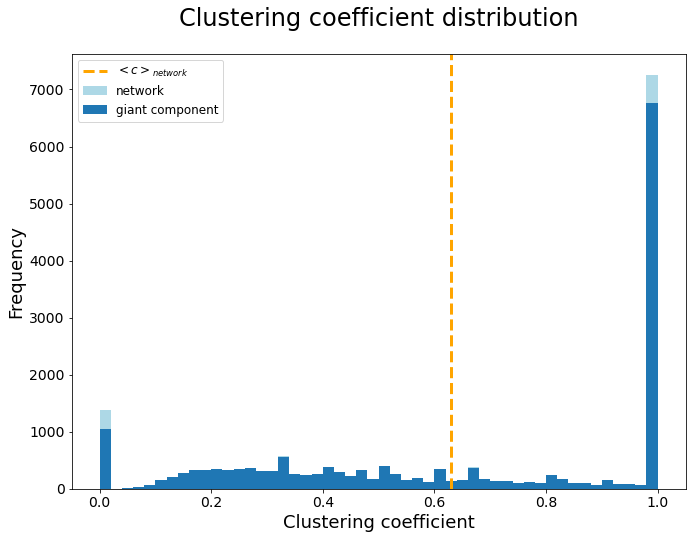

In [54]:
plt.figure(figsize=(11,8))
plt.title('Clustering coefficient distribution', fontsize=24, y=1.05)

plt.hist(clustering_coeff, bins=50, color='lightblue', label='network')
plt.hist(clustering_coeff_gc, bins=50, label='giant component')

plt.axvline(x=av_clust_coeff, color='orange', linestyle='--', linewidth=3, label=r'$<c>_{network}$')

plt.xlabel('Clustering coefficient', fontsize=18)
plt.ylabel('Frequency', fontsize=18)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.legend(loc='best', fontsize=12);

<a id='epsim'></a>

## Epidemic simulation

In [55]:
lambda_cr = gc_av_degree/(gc_av_k2 - gc_av_degree)

print("Theoric epidemic threshold = {:.2e}".format(lambda_cr))

Theoric epidemic threshold = 1.55e-02


In [56]:
prop_infected = 0.05

beta_fix = 0.1
mu_fix = 0.2

In [57]:
print('effective threshold = {:.2e}'.format(beta_fix/mu_fix))

effective threshold = 5.00e-01


In [58]:
t, S, I, R = eon.fast_SIR(giant_component,
                          beta_fix, mu_fix, 
                          rho=prop_infected)

I_max = max(I)/gc_size # peak of infection
time_of_max_infected = t[np.argmax(I)] # time to reach the peak

print("Maximum proportion of infected = {:.3f}".format(I_max))
print("Time to reach the maximum = {:.3f}".format(time_of_max_infected))

Maximum proportion of infected = 0.458
Time to reach the maximum = 2.384


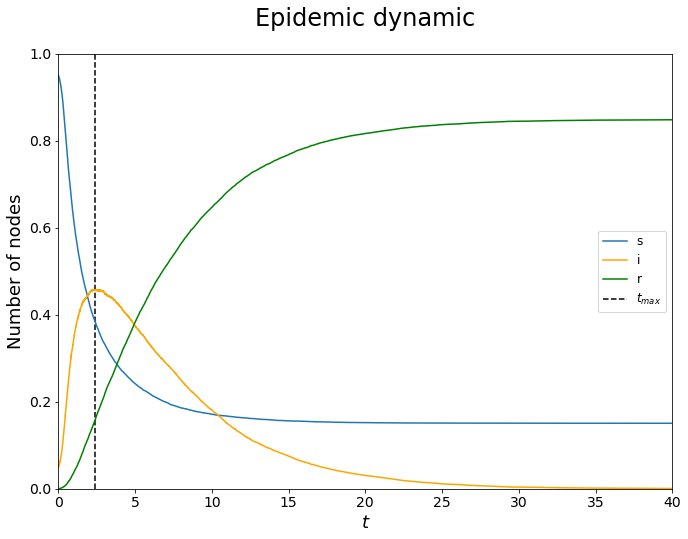

In [59]:
plt.figure(figsize=(11,8))
plt.title("Epidemic dynamic", y=1.05, fontsize=24)

plt.plot(t, S/gc_size, label = 's')
plt.plot(t, I/gc_size, label = 'i', color='orange')
plt.plot(t, R/gc_size, label = 'r', color='green')
plt.vlines(x=time_of_max_infected, ymin = 0., ymax = 1., color='black', linestyle='--', label=r'$t_{max}$')

plt.legend(loc='best', fontsize=12)

plt.xlabel('$t$', fontsize=18)
plt.ylabel('Number of nodes', fontsize=18)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.xlim(0., 40.)
plt.ylim(0.,1.);

Se scelgo $\beta$ e $\mu$ sbagliati ovviamente vado sotto la soglia.

In [60]:
beta_red = 0.01
mu_red = 0.7

t, S, I, R = eon.fast_SIR(giant_component,
                          beta_red, mu_red, 
                          rho=prop_infected)

In [61]:
print('effective threshold = {:.2e}'.format(beta_red/mu_red))

effective threshold = 1.43e-02


In [62]:
print('{:.2e}'.format(lambda_cr))

1.55e-02


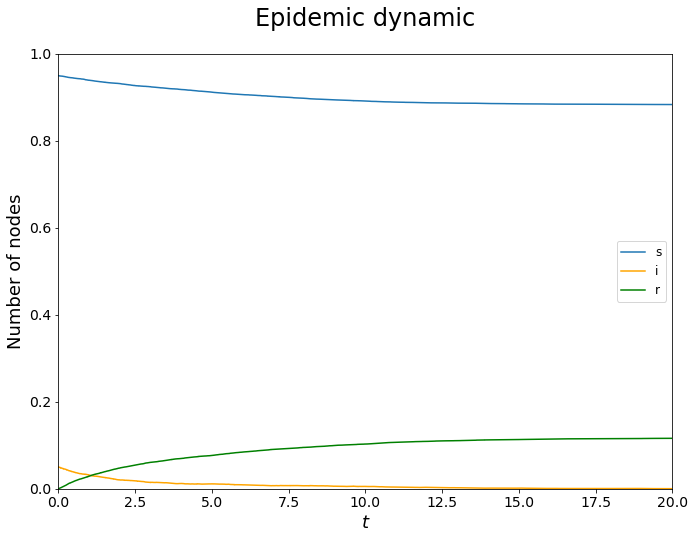

In [63]:
plt.figure(figsize=(11,8))
plt.title("Epidemic dynamic", y=1.05, fontsize=24)

plt.plot(t, S/gc_size, label = 's')
plt.plot(t, I/gc_size, label = 'i', color='orange')
plt.plot(t, R/gc_size, label = 'r', color='green')

plt.legend(loc='best', fontsize=12)

plt.xlabel('$t$', fontsize=18)
plt.ylabel('Number of nodes', fontsize=18)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.xlim(0., 20)
plt.ylim(0.,1.);

<a id='beta'></a>

### Vary $\beta$

In [64]:
mu_fix = 0.2

In [65]:
%%time

# final size of epidemic for different beta rate
final_size_rand = defaultdict(list)

for beta in np.geomspace(0.0001, 1.0, 20):

    for r in range(0, 20):

        t, S, I, R = eon.fast_SIR(giant_component, beta, mu_fix, rho=prop_infected)

        final_size_rand[beta].append(R[-1] / gc_size)

Wall time: 7min 56s


In [66]:
# creating dataframe for boxplot
homo_net_size_rand = pd.DataFrame.from_dict(final_size_rand)

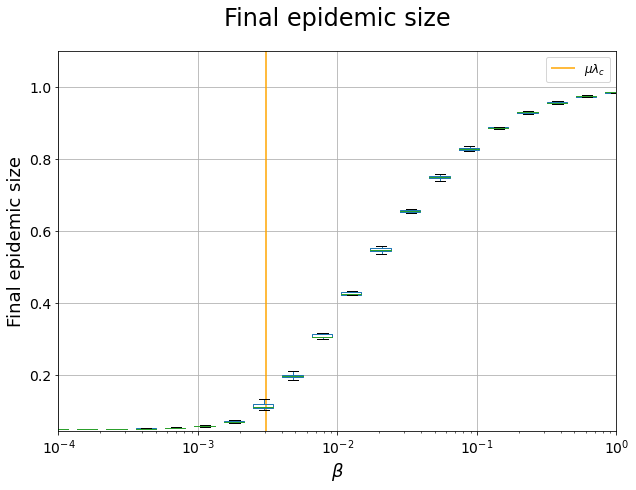

In [67]:
plt.figure(figsize=(10, 7))
plt.title("Final epidemic size", y=1.05, fontsize=24)

homo_net_size_rand.boxplot(
    positions=np.array(homo_net_size_rand.columns),
    widths=np.array(homo_net_size_rand.columns) / 3,
    showfliers=False
)

plt.vlines(x = mu_fix*lambda_cr, ymin=0.045, ymax=1.1, label=r'$\mu \lambda_{c}$', color='orange')

plt.xscale("log")
plt.xlim(0.0001, 1.0)
plt.ylim(0.045, 1.1)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.ylabel("Final epidemic size", fontsize=18)
plt.xlabel(r"$\beta$", fontsize=18)

plt.legend(loc='best', fontsize=12);

<a id='mu'></a>

### Vary $\mu$

In [68]:
beta_fix = 0.01

In [69]:
%%time

final_size_rand_mu = defaultdict(list)

for mu in np.geomspace(0.001, 1.0, 20):

    for r in range(0, 20):

        t, S, I, R = eon.fast_SIR(giant_component, 
                                  beta_fix, mu, 
                                  rho=prop_infected)

        final_size_rand_mu[mu].append(R[-1] / gc_size)

Wall time: 11min 16s


In [70]:
homo_net_size_rand_mu = pd.DataFrame.from_dict(final_size_rand_mu)

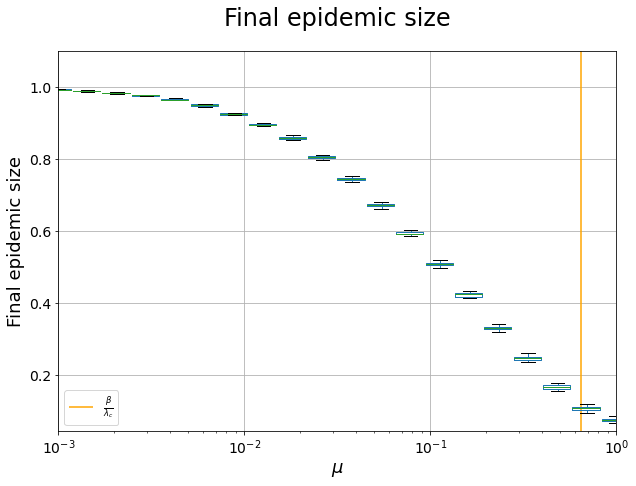

In [71]:
plt.figure(figsize=(10, 7))
plt.title("Final epidemic size", y=1.05, fontsize=24)

homo_net_size_rand_mu.boxplot(
    positions=np.array(homo_net_size_rand_mu.columns),
    widths=np.array(homo_net_size_rand_mu.columns) / 3,
    showfliers=False
)

plt.vlines(x = beta_fix/lambda_cr, ymin=0.045, ymax=1.1, label=r'$\frac{\beta}{\lambda_{c}}$', color='orange')

plt.xscale("log")
plt.xlim(0.001, 1.0)
plt.ylim(0.045, 1.1)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.ylabel('Final epidemic size', fontsize=18)
plt.xlabel(r"$\mu$", fontsize=18)

plt.legend(loc='lower left', fontsize=12);

<a id='sil_pop'></a>

### Silent population

In [72]:
# closeness
closeness_labeled = {}

for i in range(len(data1)):
    
    closeness_labeled[int(data1[i][0])] = float(data1[i][2])

# beetwenness
betweenness_labeled = {}

for i in range(len(data2)):
    
    betweenness_labeled[int(data2[i][0])] = float(data2[i][1])

# eigenvector centrality -> eigenvec

# pagerank -> pr esiste già

In [73]:
def find_central_nodes(centrality_measure, n):
    '''
    Select the label of the more central nodes according to a certain centrality measure
     
    Parameters
    ----------
    centrality_measure : dict-like object, contains the nodes label as keys and a certain centrality measure as values
    n : number of nodes to be selected
     
    Returns
    -------
    central_nodes : dict with label of more central nodes and centrality measure
    '''
        
    n = int(n)
    max_values = nlargest(n, centrality_measure.values())
    max_keys = nlargest(n, centrality_measure, key=lambda k: centrality_measure[k])
    
    # central_nodes = dict(zip(max_keys, max_values))
    
    return max_keys, max_values

In [74]:
def simulation(graph, beta, mu, ic, run):
    '''
    con questa funzione io vorrei calcolare tutte e tre le metriche che voglio studiare
    
    Prameters
    ---------
    graph : NetworkX graph
    beta : transmission rate
    mu : recovery rate
    ic : initial proportion of infected nodes
    run : number of simulation
    
    Returns
    I_max : array, fraction of infectious at peak of infection
    t_max : array, time to reach the peak
    final_size : array, final size of infection
    -------
    '''
    run = int(run)
    # size = graph.number_of_nodes()
    I_max = []
    t_max = []
    final_size = []
    
    for r in range(0, run):
        
        t, S, I, R = eon.fast_SIR(graph, beta, mu, rho=ic)
        
        I_max.append(max(I)/gc_size)
        t_max.append(t[np.argmax(I)])
        final_size.append(R[-1]/float(gc_size))
        
    return I_max, t_max, final_size 

In [75]:
I_centr = []
t_centr = []
fs_centr = []

In [76]:
# numero di iterazioni per simulation
runs = 50

# numero di frazioni
n_frac = 20

In [77]:
prop_infected = 0.05

beta_fix = 0.1
mu_fix = 0.2

<a id='deg_sil'></a>

- #### grado

In [78]:
%%time
# eventualmente posso passare da 10 a 20/ 30 se il pc ce la fa

I_max = {}
t_max = {}
final_size = {}

for n in np.linspace(0, 0.9, n_frac):
    
    # cerco i nodi di grado massimo
    central_nodes, _ = find_central_nodes(dict(giant_component.degree()), n*gc_size)
    # creo il sottografo
    H = giant_component.copy()
    H.remove_nodes_from(central_nodes)
    
    # simulo l'epidemia sul sottografo che ho ottenuto (50 run, a 20 ci sta)
    I_max[n], t_max[n], final_size[n] = simulation(H, beta_fix, mu_fix, prop_infected, runs)

Wall time: 5min 10s


In [79]:
I_centr.append(I_max)
t_centr.append(t_max)
fs_centr.append(final_size)

<a id='clo_sil'></a>

- **Closeness**

In [80]:
%%time
# eventualmente posso passare da 10 a 20/ 30 se il pc ce la fa

I_max = {}
t_max = {}
final_size = {}

for n in np.linspace(0, 0.9, n_frac):
    
    # cerco i nodi di grado massimo
    central_nodes, _ = find_central_nodes(closeness_labeled, n*gc_size)
    # creo il sottografo
    H = giant_component.copy()
    H.remove_nodes_from(central_nodes)
    
    # simulo l'epidemia sul sottografo che ho ottenuto (20 run)
    I_max[n], t_max[n], final_size[n] = simulation(H, beta_fix, mu_fix, prop_infected, runs)

Wall time: 5min 49s


In [81]:
I_centr.append(I_max)
t_centr.append(t_max)
fs_centr.append(final_size)

<a id='bet_sil'></a>

- **Betweenness**

In [82]:
%%time
# eventualmente posso passare da 10 a 20/ 30 se il pc ce la fa

I_max = {}
t_max = {}
final_size = {}

for n in np.linspace(0, 0.9, n_frac):
    
    # cerco i nodi di grado massimo
    central_nodes, _ = find_central_nodes(betweenness_labeled, n*gc_size)
    # creo il sottografo
    H = giant_component.copy()
    H.remove_nodes_from(central_nodes)
    
    # simulo l'epidemia sul sottografo che ho ottenuto (20 run)
    I_max[n], t_max[n], final_size[n] = simulation(H, beta_fix, mu_fix, prop_infected, runs)

Wall time: 5min 1s


In [83]:
I_centr.append(I_max)
t_centr.append(t_max)
fs_centr.append(final_size)

<a id='eig_sil'></a>

- **Eigenvector centrality**

In [84]:
%%time
# eventualmente posso passare da 10 a 20/ 30 se il pc ce la fa

I_max = {}
t_max = {}
final_size = {}

for n in np.linspace(0, 0.9, n_frac):
    
    # cerco i nodi di grado massimo
    central_nodes, _ = find_central_nodes(eigenvec, n*gc_size)
    # creo il sottografo
    H = giant_component.copy()
    H.remove_nodes_from(central_nodes)
    
    # simulo l'epidemia sul sottografo che ho ottenuto (20 run)
    I_max[n], t_max[n], final_size[n] = simulation(H, beta_fix, mu_fix, prop_infected, runs)

Wall time: 6min 43s


In [85]:
I_centr.append(I_max)
t_centr.append(t_max)
fs_centr.append(final_size)

<a id='pr_sil'></a>

- **Pagerank**

In [86]:
%%time
# eventualmente posso passare da 10 a 20/ 30 se il pc ce la fa

I_max = {}
t_max = {}
final_size = {}

for n in np.linspace(0, 0.9, n_frac):
    
    # cerco i nodi di grado massimo
    central_nodes, _ = find_central_nodes(pr, n*gc_size)
    # creo il sottografo
    H = giant_component.copy()
    H.remove_nodes_from(central_nodes)
    
    # simulo l'epidemia sul sottografo che ho ottenuto (20 run)
    I_max[n], t_max[n], final_size[n] = simulation(H, beta_fix, mu_fix, prop_infected, runs)

Wall time: 4min 39s


In [87]:
I_centr.append(I_max)
t_centr.append(t_max)
fs_centr.append(final_size)

Check sugli array

In [88]:
len(I_centr)

5

In [89]:
len(t_centr)

5

In [90]:
len(fs_centr)

5

Plot results.

In [91]:
color=['purple', 'orange', '#1f77b4', 'violet', 'green']
label_centr = ['Degree', 'Closeness', 'Betweenness', 'Eigenvector', 'Pagerank']

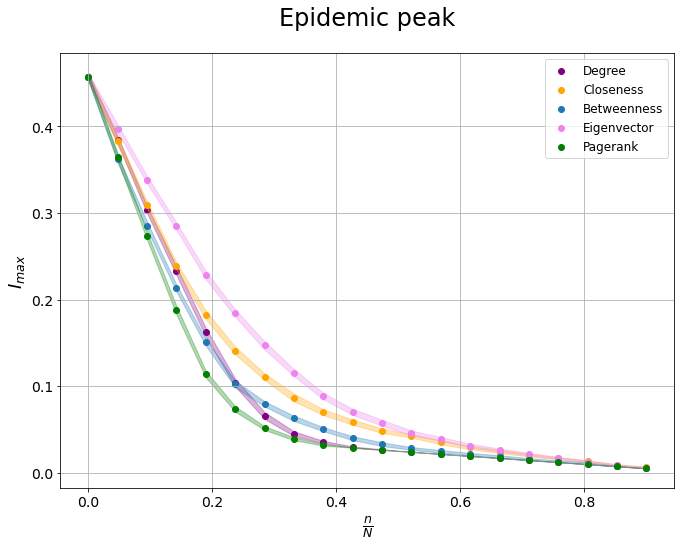

In [92]:
plt.figure(figsize=(11,8))
plt.title('Epidemic peak', y=1.05, fontsize=24)

for i in range(len(I_centr)):
    plt.scatter(
                [n for n, j in I_centr[i].items()],
                [mean(j) for n, j in I_centr[i].items()],
                label=label_centr[i],
                color=color[i]
               )

    plt.fill_between(
                     [n for n, j in I_centr[i].items()],
                     [mean(j) - std(j) for n, j in I_centr[i].items()],
                     [mean(j) + std(j) for n, j in I_centr[i].items()],
                     alpha=0.3,
                     color=color[i]
                    );

plt.xlabel(r'$\frac{n}{N}$', fontsize=18)
plt.ylabel(r'$I_{max}$', fontsize=18)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.legend(loc='best', fontsize=12)
plt.grid(True)

plt.savefig("Picco.png");

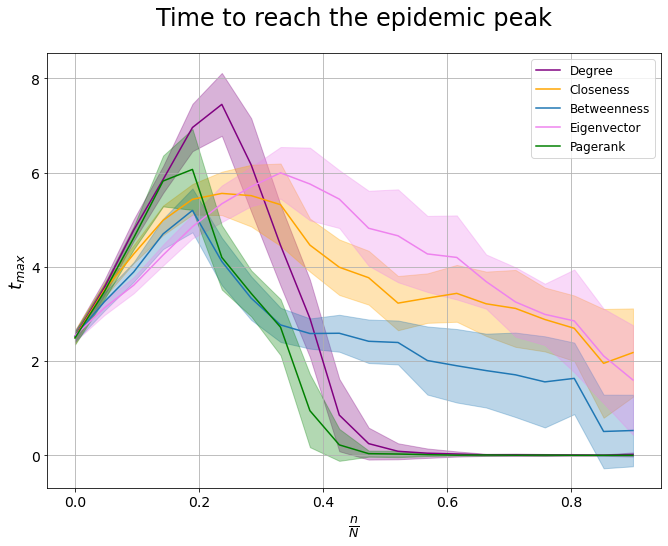

In [93]:
plt.figure(figsize=(11,8))
plt.title('Time to reach the epidemic peak', y=1.05, fontsize=24)

for i in range(len(t_centr)):
    plt.plot(
                [n for n, j in t_centr[i].items()],
                [mean(j) for n, j in t_centr[i].items()],
                label=label_centr[i],
                color=color[i]
               )

    plt.fill_between(
                     [n for n, j in t_centr[i].items()],
                     [mean(j) - std(j) for n, j in t_centr[i].items()],
                     [mean(j) + std(j) for n, j in t_centr[i].items()],
                     alpha=0.3,
                     color=color[i]
                    );

plt.xlabel(r'$\frac{n}{N}$', fontsize=18)
plt.ylabel(r'$t_{max}$', fontsize=18)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.legend(loc='best', fontsize=12)
plt.grid(True)

plt.savefig('Tempo.png');

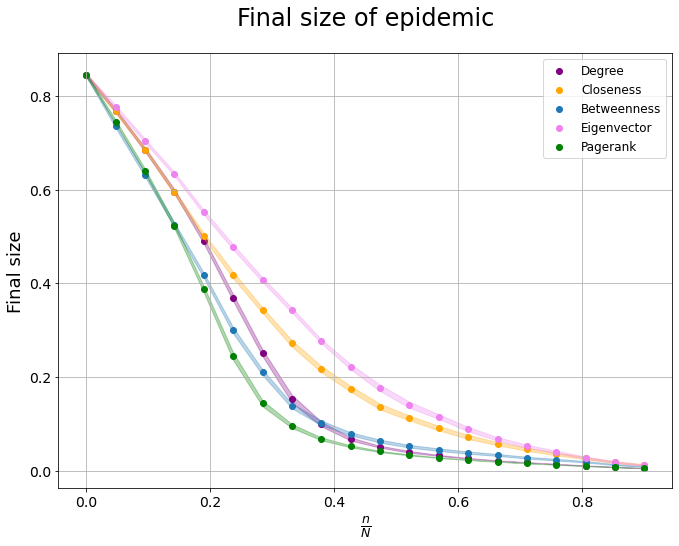

In [94]:
plt.figure(figsize=(11,8))
plt.title('Final size of epidemic', y=1.05, fontsize=24)

for i in range(len(fs_centr)):
    plt.scatter(
                [n for n, j in fs_centr[i].items()],
                [mean(j) for n, j in fs_centr[i].items()],
                label=label_centr[i],
                color=color[i]
               )

    plt.fill_between(
                     [n for n, j in fs_centr[i].items()],
                     [mean(j) - std(j) for n, j in fs_centr[i].items()],
                     [mean(j) + std(j) for n, j in fs_centr[i].items()],
                     alpha=0.3,
                     color=color[i]
                    );

plt.xlabel(r'$\frac{n}{N}$', fontsize=18)
plt.ylabel('Final size', fontsize=18)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.legend(loc='best', fontsize=12)
plt.grid(True)

plt.savefig('fs.png');